# Notebook 02 — Modelado y Evaluación
## CommonLit: Evaluate Student Summaries

**Reto #12** | CC3084 Data Science — UVG, Semestre II 2026

Este notebook entrena y evalúa múltiples modelos de regresión para predecir
las puntuaciones `content` y `wording` de resúmenes estudiantiles.

### Secciones
1. Configuración e imports
2. Carga y preprocesamiento de datos
3. Extracción de features
4. Entrenamiento y evaluación de modelos
5. Visualización de resultados
6. Persistencia de modelos
7. Conclusiones

## 1. Configuración e imports

Agregamos el directorio raíz al `sys.path` para poder importar el paquete `src`.

In [25]:
import sys
from pathlib import Path

# Agregar raíz del proyecto al path para importar src/
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Módulos del proyecto
from src import config
from src.preprocessing import load_and_merge, check_quality, add_length_features
from src.features import build_feature_matrix, build_tfidf_matrix, build_numeric_features, scale_numeric_features
from src.models import (
    get_model_catalog, train_evaluate_all, split_data,
    save_model, list_trained_models, compute_metrics
)
from src.visualization import (
    plot_model_comparison, plot_actual_vs_predicted
)

print(f'Raíz del proyecto: {ROOT}')
print(f'Semilla aleatoria: {config.RANDOM_SEED}')

Raíz del proyecto: /Users/joseruiz_002/Documents/UVG/8to Semestre/Data Science/Evaluate-Student-Summaries
Semilla aleatoria: 42


## 2. Carga y preprocesamiento de datos

In [26]:
# Cargar y fusionar resúmenes con prompts
df = load_and_merge(split="train")
print(f"Forma del dataset: {df.shape}")
df.head(3)

Forma del dataset: (7165, 8)


,student_id,prompt_id,text,content,wording,prompt_question,prompt_title,prompt_text
0,000e8c3c7ddb,814d6b,The third wave was an experimentto see how peo...,0.205683,0.380538,Summarize how the Third Wave developed over su...,The Third Wave,Background \nThe Third Wave experiment took pl...
1,0020ae56ffbf,ebad26,They would rub it up with soda to make the sme...,-0.548304,0.506755,Summarize the various ways the factory would u...,Excerpt from The Jungle,"With one member trimming beef in a cannery, an..."
2,004e978e639e,3b9047,"In Egypt, there were many occupations and soci...",3.128928,4.231226,"In complete sentences, summarize the structure...",Egyptian Social Structure,Egyptian society was structured like a pyramid...


In [27]:
# Verificar calidad de datos
quality = check_quality(df)
print("Valores faltantes:")
print(quality['missing'])
print(f"\nFilas duplicadas: {quality['duplicates']}")
print(f"Dataset válido: {quality['valid']}")

Valores faltantes:
student_id         0
prompt_id          0
text               0
content            0
wording            0
prompt_question    0
prompt_title       0
prompt_text        0
dtype: int64

Filas duplicadas: 0
Dataset válido: True


In [28]:
# Agregar features de longitud
df = add_length_features(df)
print("Columnas disponibles:", df.columns.tolist())

Columnas disponibles: ['student_id', 'prompt_id', 'text', 'content', 'wording', 'prompt_question', 'prompt_title', 'prompt_text', 'text_len_words', 'text_len_chars']


## 3. Extracción de features

Construimos la matriz de features combinando:
- **TF-IDF** sobre el texto del resumen (unigramas + bigramas, top 5,000)
- **Features numéricas**: longitud en palabras, longitud en caracteres, ratio vs prompt

In [29]:
X, _ = build_feature_matrix(df)
print(f"Forma de la matriz de features: {X.shape}")

Forma de la matriz de features: (7165, 5003)


## 4. Entrenamiento y evaluación de modelos

Entrenamos y evaluamos los 4 algoritmos para cada uno de los 2 targets:
- `content`: qué tan bien el resumen representa la idea principal
- `wording`: calidad del lenguaje (claridad, precisión, fluidez)

**División**: 80% entrenamiento / 20% prueba (semilla fija para reproducibilidad).

In [30]:
all_results = []
trained_models = {}

for target in config.TARGET_COLS:
    print(f"\n{'='*50}")
    print(f"  TARGET: {target.upper()}")
    print(f"{'='*50}")

    y = df[target].values
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2)
    print(f"  Train: {X_train.shape} | Test: {X_test.shape}")

    results = train_evaluate_all(X_train, y_train, X_test, y_test, target_name=target)
    all_results.append(results)

    # Guardar modelos entrenados en memoria para persistirlos después
    catalog = get_model_catalog()
    for model_name, model in catalog.items():
        model.fit(X_train, y_train)
        trained_models[(model_name, target)] = (model, X_test, y_test)

results_df = pd.concat(all_results, ignore_index=True)
print("\n\n--- Tabla de métricas ---")
results_df.sort_values(["target", "rmse"]).to_string(index=False)


  TARGET: CONTENT
  Train: (5732, 5003) | Test: (1433, 5003)

  TARGET: WORDING
  Train: (5732, 5003) | Test: (1433, 5003)


--- Tabla de métricas ---


'              modelo  target     rmse      mae       r2\nHistGradientBoosting content 0.453466 0.347390 0.813270\n        RandomForest content 0.479644 0.364162 0.791088\n               Ridge content 0.492922 0.377158 0.779362\n               Lasso content 0.627924 0.477783 0.641954\nHistGradientBoosting wording 0.637015 0.500082 0.604088\n               Ridge wording 0.640644 0.500334 0.599565\n        RandomForest wording 0.677657 0.530372 0.551958\n               Lasso wording 0.850209 0.678013 0.294738'

In [31]:
# Tabla de resultados formateada
results_df.sort_values(["target", "rmse"]).style.background_gradient(
    subset=["rmse", "mae"], cmap="RdYlGn_r"
).background_gradient(
    subset=["r2"], cmap="RdYlGn"
).format({"rmse": "{:.4f}", "mae": "{:.4f}", "r2": "{:.4f}"})

,modelo,target,rmse,mae,r2
3,HistGradientBoosting,content,0.4535,0.3474,0.8133
2,RandomForest,content,0.4796,0.3642,0.7911
0,Ridge,content,0.4929,0.3772,0.7794
1,Lasso,content,0.6279,0.4778,0.6420
7,HistGradientBoosting,wording,0.6370,0.5001,0.6041
4,Ridge,wording,0.6406,0.5003,0.5996
6,RandomForest,wording,0.6777,0.5304,0.5520
5,Lasso,wording,0.8502,0.6780,0.2947


## 5. Visualización de resultados

### 5.1 Comparación de modelos por métrica

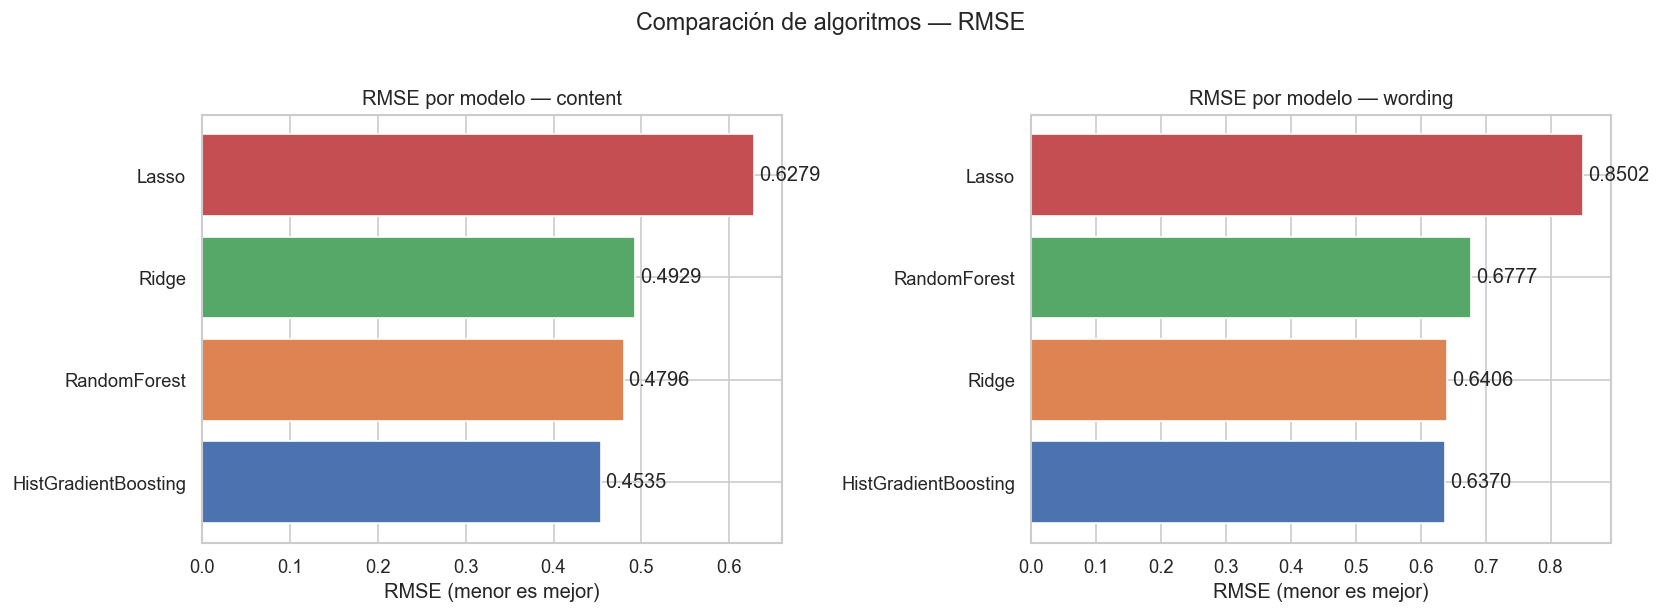

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, config.TARGET_COLS):
    subset = results_df[results_df["target"] == target].sort_values("rmse")
    bars = ax.barh(subset["modelo"], subset["rmse"],
                   color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
    ax.set_title(f"RMSE por modelo — {target}")
    ax.set_xlabel("RMSE (menor es mejor)")
    ax.bar_label(bars, fmt="%.4f", padding=3)

plt.suptitle("Comparación de algoritmos — RMSE", fontsize=14, y=1.02)
plt.tight_layout()

# Guardar figura estática
fig.savefig(ROOT / "reports" / "figures" / "model_comparison_rmse.png",
            bbox_inches="tight", dpi=150)
plt.show()

### 5.2 Real vs Predicho para el mejor modelo

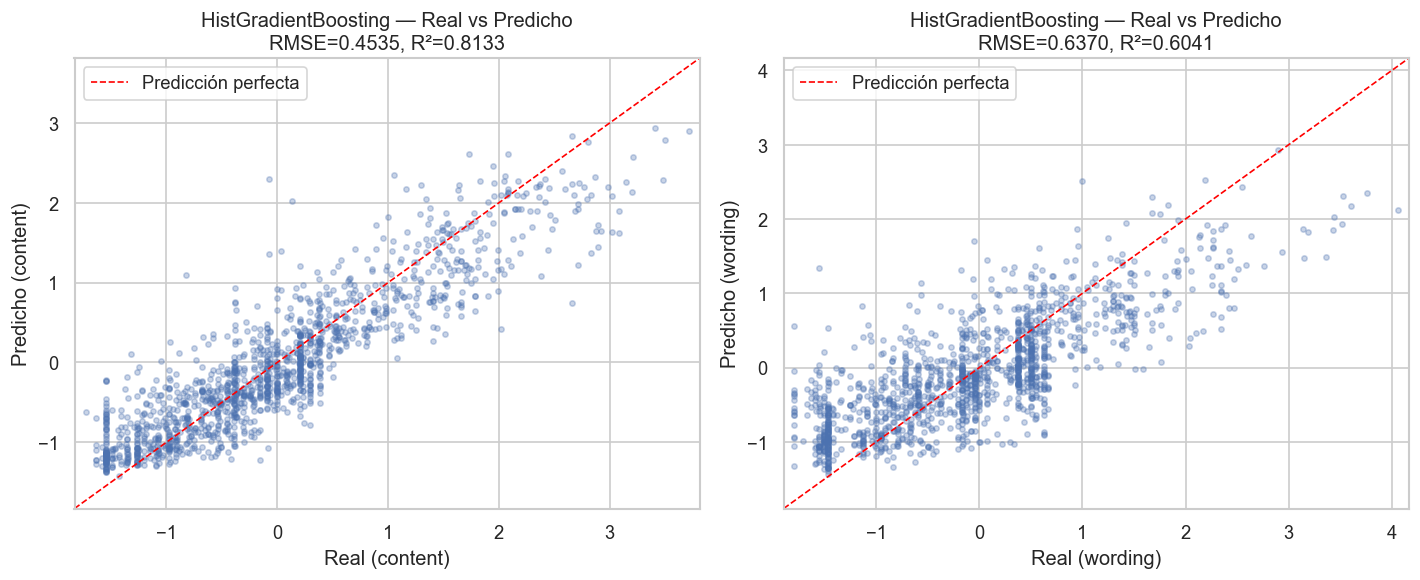

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, target in zip(axes, config.TARGET_COLS):
    # Seleccionar el modelo con menor RMSE para este target
    best_row = results_df[results_df["target"] == target].sort_values("rmse").iloc[0]
    best_name = best_row["modelo"]
    model, X_test, y_test = trained_models[(best_name, target)]
    y_pred = model.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="#4C72B0")
    lim = [min(y_test.min(), y_pred.min()) - 0.1,
           max(y_test.max(), y_pred.max()) + 0.1]
    ax.plot(lim, lim, "r--", lw=1, label="Predicción perfecta")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel(f"Real ({target})")
    ax.set_ylabel(f"Predicho ({target})")
    ax.set_title(f"{best_name} — Real vs Predicho\nRMSE={best_row['rmse']:.4f}, R²={best_row['r2']:.4f}")
    ax.legend()

plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "actual_vs_predicted.png",
            bbox_inches="tight", dpi=150)
plt.show()

### 5.3 R² de todos los modelos

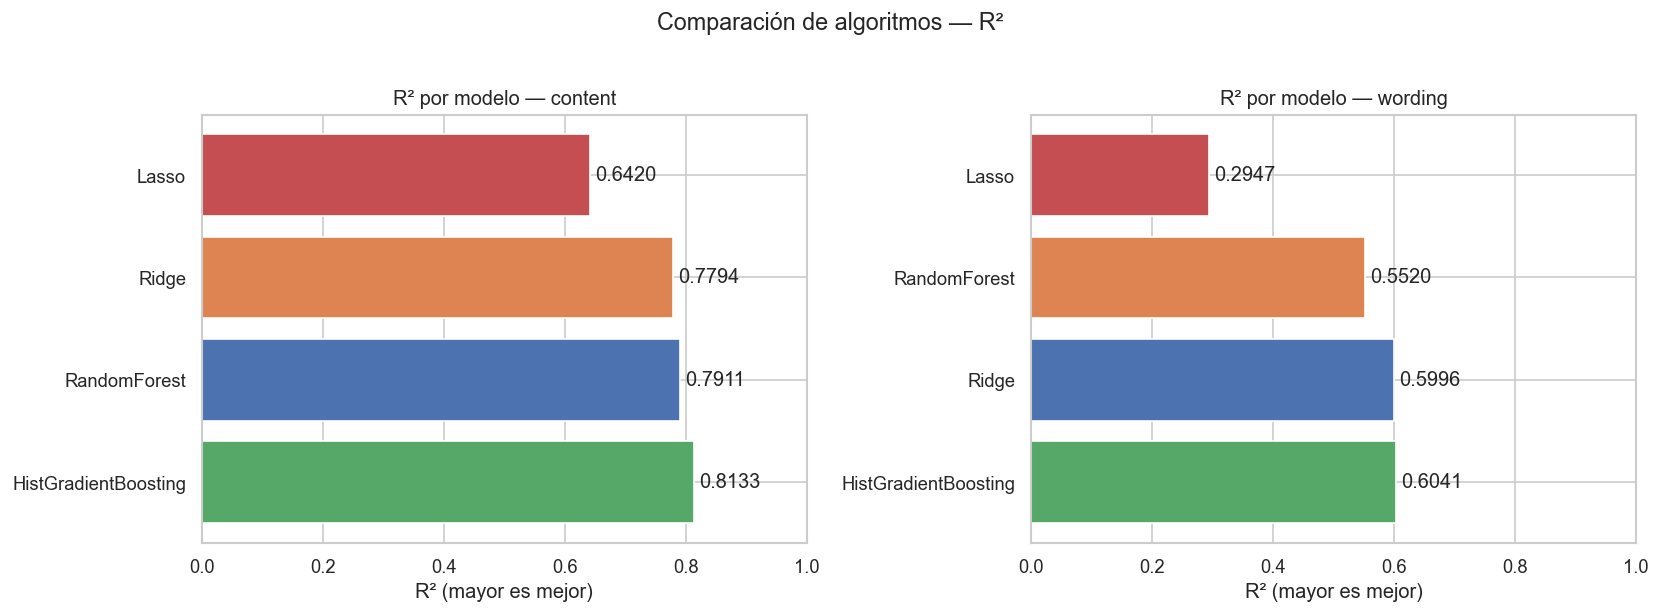

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, config.TARGET_COLS):
    subset = results_df[results_df["target"] == target].sort_values("r2", ascending=False)
    bars = ax.barh(subset["modelo"], subset["r2"],
                   color=["#55A868", "#4C72B0", "#DD8452", "#C44E52"])
    ax.set_title(f"R² por modelo — {target}")
    ax.set_xlabel("R² (mayor es mejor)")
    ax.set_xlim(0, 1)
    ax.bar_label(bars, fmt="%.4f", padding=3)

plt.suptitle("Comparación de algoritmos — R²", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "model_comparison_r2.png",
            bbox_inches="tight", dpi=150)
plt.show()

## 6. Persistencia de modelos

Guardamos todos los modelos entrenados en `models/` para que la app Streamlit
pueda cargarlos sin necesidad de reentrenar.

In [35]:
for (model_name, target), (model, _, _) in trained_models.items():
    path = save_model(model, model_name, target)
    print(f"Guardado: {path.name}")

print("\nModelos disponibles:")
for m in list_trained_models():
    print(f"  {m['name']} → target={m['target']}")

Guardado: Ridge_content.pkl
Guardado: Lasso_content.pkl
Guardado: RandomForest_content.pkl
Guardado: HistGradientBoosting_content.pkl
Guardado: Ridge_wording.pkl
Guardado: Lasso_wording.pkl
Guardado: RandomForest_wording.pkl
Guardado: HistGradientBoosting_wording.pkl

Modelos disponibles:
  HistGradientBoosting → target=content
  HistGradientBoosting → target=wording
  Lasso → target=content
  Lasso → target=wording
  RandomForest → target=content
  RandomForest → target=wording
  Ridge → target=content
  Ridge → target=wording
  numeric → target=scaler
  tfidf → target=vectorizer


In [36]:
# Guardar también la matriz de features y el vectorizer para la app
import joblib
from src.features import build_tfidf_matrix, build_numeric_features, scale_numeric_features

# Reentrenar vectorizer y scaler sobre todos los datos de entrenamiento
tfidf_train, _, vectorizer = build_tfidf_matrix(df[config.TEXT_COL])
num_features = build_numeric_features(df)
_, _, scaler = scale_numeric_features(num_features)

joblib.dump(vectorizer, ROOT / 'models' / 'tfidf_vectorizer.pkl')
joblib.dump(scaler, ROOT / 'models' / 'numeric_scaler.pkl')
print('Vectorizer y scaler guardados en models/')

Vectorizer y scaler guardados en models/


## 7. Conclusiones

En esta sección se comparan los 4 algoritmos evaluados y se selecciona el mejor
para cada target. Los hallazgos se documentan aquí para incluirlos en el informe.

**Puntos a discutir:**
- ¿Qué modelo obtiene menor RMSE para `content`?
- ¿Qué modelo obtiene menor RMSE para `wording`?
- ¿Hay evidencia de overfitting (diferencia entre RMSE train vs test)?
- ¿Qué features contribuyen más según la importancia de variables (RandomForest)?
- ¿Qué pasos de tuning de hiperparámetros mejorarían los resultados?

*(Completa esta sección con los hallazgos de tu ejecución)*